In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
import os                                                                                                                                                                                                        
os.makedirs('../reports', exist_ok=True)

In [3]:
conn = sqlite3.connect('../data/olist.db')

orders = pd.read_sql('SELECT * FROM orders', conn)
order_items = pd.read_sql('SELECT * from order_items', conn)
reviews = pd.read_sql('SELECT * FROM reviews', conn)
customers = pd.read_sql('SELECT * FROM customers', conn)
products = pd.read_sql('SELECT * FROM products', conn)
translations = pd.read_sql('SELECT * FROM translations', conn)

conn.close()

In [4]:
# Zakres analizy: tylko zamówienia dostarczone (spójnie z SQL i business_conclusions)
orders = orders[orders['order_status'] == 'delivered'].copy()

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['hour'] = orders['order_purchase_timestamp'].dt.hour
orders['weekday'] = orders['order_purchase_timestamp'].dt.dayofweek

In [5]:
heatmap_data = orders.pivot_table(index='weekday', columns='hour', values='order_id', aggfunc='count')

In [6]:
heatmap_data


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
0,315,132,63,34,21,22,64,157,471,752,...,1063,1047,1060,954,891,920,998,1083,962,697
1,300,151,79,28,28,24,69,216,510,845,...,1095,1005,1059,943,852,894,946,996,939,676
2,385,171,81,31,33,24,91,208,497,798,...,1027,952,1008,943,818,822,881,927,855,600
3,345,165,74,38,30,28,82,211,495,736,...,951,901,1042,881,759,798,816,826,835,533
4,412,210,66,46,39,35,91,203,487,754,...,937,948,943,791,697,757,714,700,675,496
5,308,167,65,41,25,23,51,102,245,421,...,650,700,676,674,693,729,708,645,535,422
6,256,137,68,41,27,26,30,102,202,341,...,660,696,688,777,875,881,944,863,858,591


## Wykres 1: Heatmapa zamówień per dzień tygodnia i godzina

**Obserwacje** (zamówienia delivered):
- Dni robocze (0-4) generują wyraźnie więcej zamówień niż weekend; sobota (5) to najsłabszy dzień
- Aktywność koncentruje się w paśmie 10-16 — najlepsza godzina zagregowana po wszystkich dniach to **16:00**
- Najwyższa pojedyncza komórka: **wtorek 14:00 (~1,1 tys. zamówień)**; drugi, mniejszy szczyt wieczorny ok. 20-21
- Niedziela ma najniższy wolumen dzienny, ale **najwyższy udział wieczoru: 38% zamówień pada w godz. 18-22** (vs 26-31% w pozostałe dni) — klienci planują zakupy przed nowym tygodniem
- Martwa strefa: 2:00-6:00 we wszystkich dniach (<100 zamówień)
- Wniosek biznesowy: kampanie konwersyjne celować w godz. 10-16 dni roboczych, push/e-mail zaangażowaniowy w niedzielę wieczorem

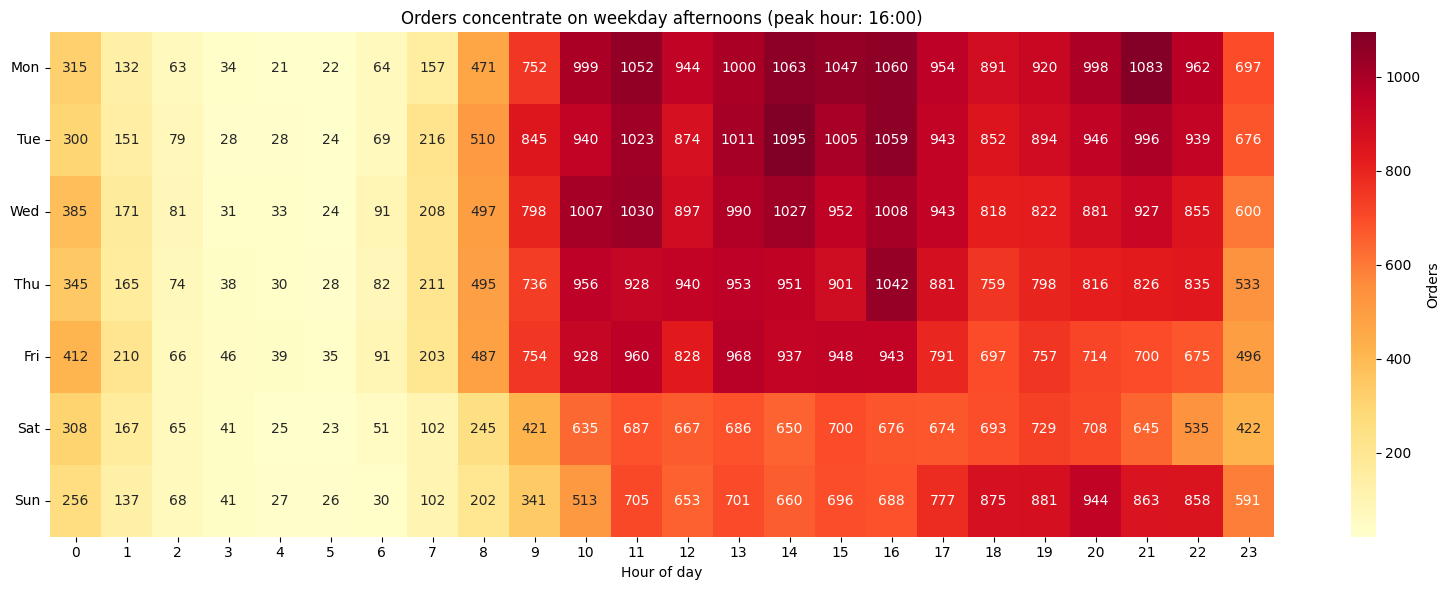

In [7]:
plt.figure(figsize=(16,6))
ax = sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f',
                 cbar_kws={'label': 'Orders'})
ax.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
plt.xlabel('Hour of day')
plt.ylabel('')
plt.title('Orders concentrate on weekday afternoons (peak hour: 16:00)')
plt.tight_layout()
plt.savefig('../reports/heatmap_orders.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
df = orders.merge(customers, on='customer_id')

In [9]:
# orders już przefiltrowane do delivered
top_states = df['customer_state'].value_counts().head(10).index
df_top = df[df['customer_state'].isin(top_states)]

  ## Wykres 2: Czas dostawy per stan (top 10)                                                                                                                                                                      
                                                                                                                                                                                                                   
  **Obserwacje:**                                                                                                                                                                                                  
  - SP ma najkrótszą medianę (~8 dni) — największy hub logistyczny Brazylii
  - BA ma najszerszy box i wyższą medianę (~20 dni) — północno-wschodnie stany gorzej obsługiwane                                                                                                                  
  - Outliery 150-200 dni we wszystkich stanach — patologiczne przypadki do zbadania                                                                                                                                
  - Geografia mocno wpływa na czas dostawy (potwierdzenie analizy SQL)
  

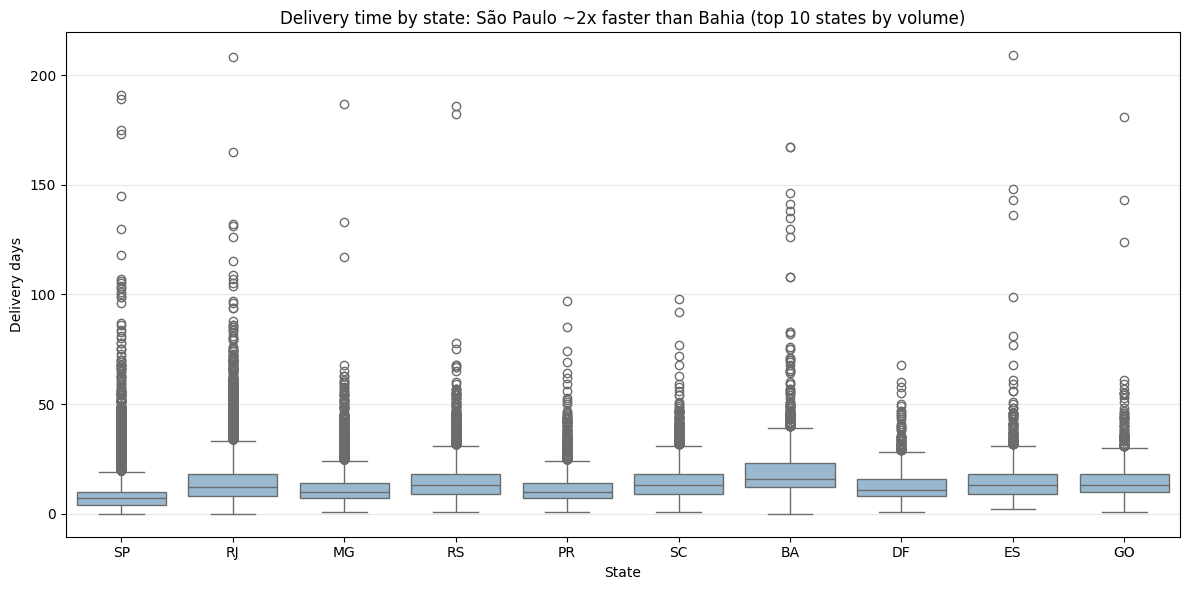

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='customer_state', y='delivery_days', data=df_top, order=top_states,
            color='#8FBBD9')
plt.title('Delivery time by state: São Paulo ~2x faster than Bahia (top 10 states by volume)')
plt.xlabel('State')
plt.ylabel('Delivery days')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/boxplot_delivery.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Tylko pozycje z zamówień delivered (orders jest już przefiltrowane wyżej)
df_cat = order_items.merge(orders[['order_id']], on='order_id')
df_cat = df_cat.merge(products, on='product_id')
name_map = dict(zip(translations['product_category_name'], translations['product_category_name_english']))
df_cat['category_en'] = df_cat['product_category_name'].map(name_map)
top15 = df_cat.groupby('category_en')['price'].sum().nlargest(15)

In [12]:
top15

category_en
health_beauty            1233131.72
watches_gifts            1166176.98
bed_bath_table           1023434.76
sports_leisure            954852.55
computers_accessories     888724.61
furniture_decor           711927.69
housewares                615628.69
cool_stuff                610204.10
auto                      578966.65
toys                      471286.48
garden_tools              470495.28
baby                      400421.84
perfumery                 390144.65
telephony                 309860.23
office_furniture          268154.31
Name: price, dtype: float64

## Wykres 3: Top 15 kategorii po przychodzie

**Obserwacje** (zamówienia delivered):
- #1 health_beauty (~1,23 mln BRL), #2 watches_gifts (~1,17 mln BRL) — razem dominują
- Top 5 kategorii (health_beauty, watches_gifts, bed_bath_table, sports_leisure, computers_accessories) generuje ~50% przychodu top 15
- Kategorie domowe silne: bed_bath_table, furniture_decor, housewares — łącznie duży udział
- office_furniture na dole (~268 tys. BRL) — mało przychodu + najniższy rating z SQL (3.49) — kandydat do programu naprawczego (szczegóły: sql/03, zapytanie 1)
- Wniosek biznesowy: inwestować w health_beauty i watches_gifts (wysoki przychód), naprawić office_furniture (niski przychód + niski rating = problem operacyjny dominatora)

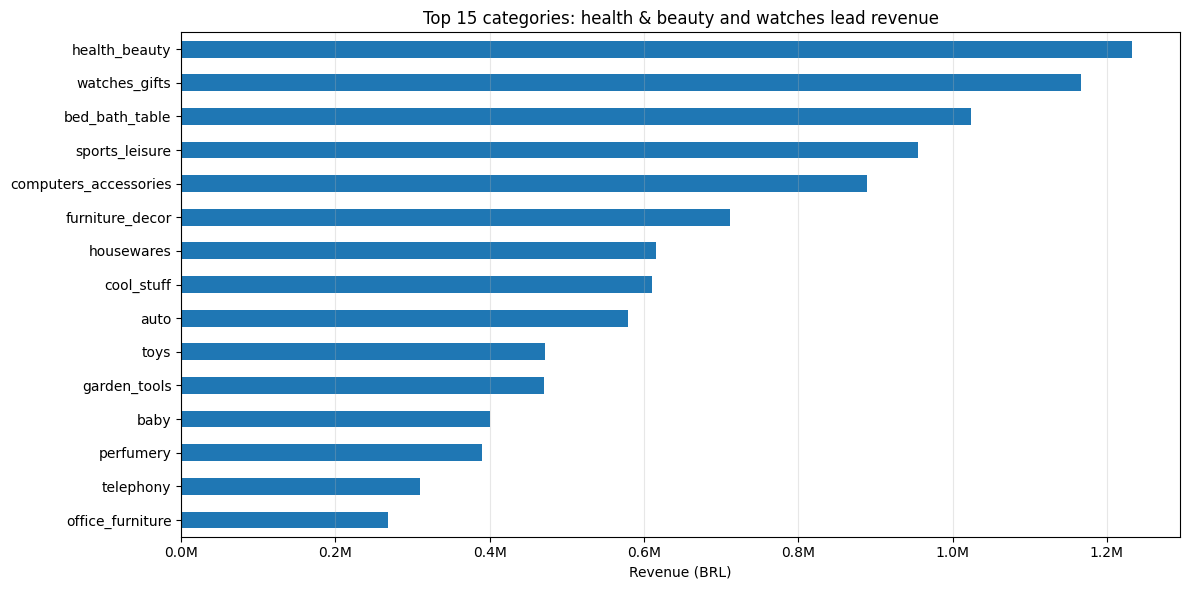

In [13]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(12, 6))
top15.sort_values().plot(kind='barh', color='#1f77b4', ax=ax)
ax.set_title('Top 15 categories: health & beauty and watches lead revenue')
ax.set_xlabel('Revenue (BRL)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/barh_top15_categories.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# orders jest już przefiltrowane do delivered, timestamp już jako datetime
df_rev = orders.merge(order_items, on='order_id')
df_rev['month'] = df_rev['order_purchase_timestamp'].dt.to_period('M')
monthly_rev = df_rev.groupby('month')['price'].sum()

  ## Wykres 4: Trend przychodu miesięcznego                                                                                                                                                                        
                                                                                                                                                                                                                   
  **Obserwacje:**                             
  - Wyraźny trend wzrostowy: od ~0 (Q4 2016) do ~1M BRL/mies (2018)                                                                                                                                                
  - Black Friday (Nov 2017) — ostry spike do ~990k BRL, potem spadek w grudniu                                                                                                                                     
  - Stabilizacja od Jan 2018 na poziomie ~850-970k BRL                                                                                                                                                             
  - Spadek Nov 2016 → Jan 2017 (~0) — prawdopodobnie początek działalności platformy, mało danych                                                                                                                  
  - Sezonowość: lekkie dołki w lutym/marcu (po świętach)                                                                                                                                                           
  - Wniosek biznesowy: platforma w fazie wzrostu, Black Friday to kluczowy event sprzedażowy, po 2017 wzrost się spłaszcza — potrzebne nowe drivery (retencja, nowe kategorie)

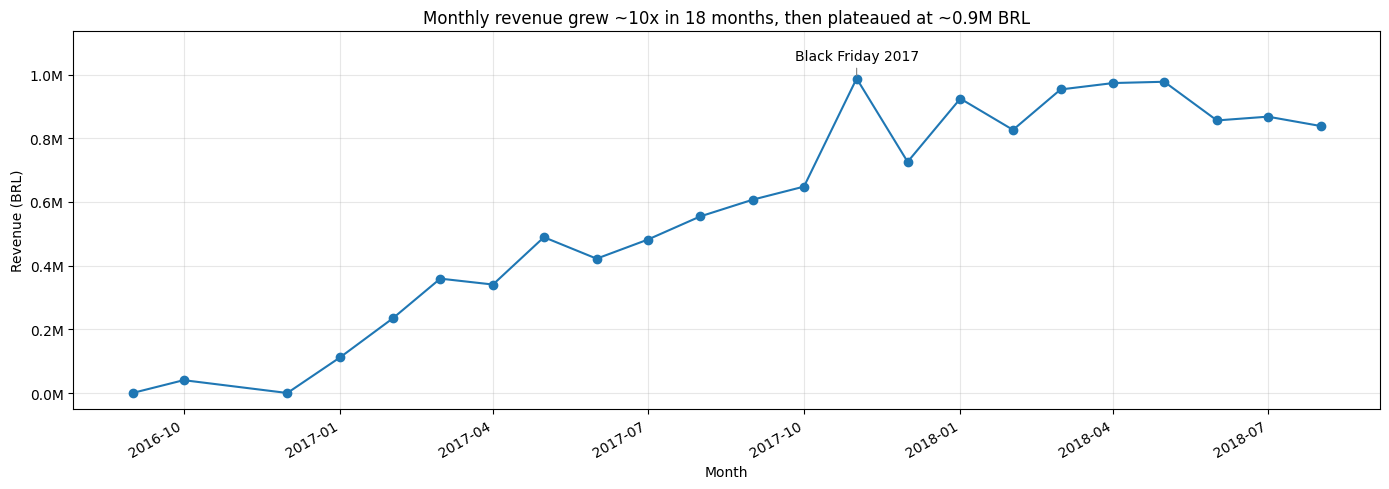

In [15]:
from matplotlib.ticker import FuncFormatter

mr = monthly_rev.copy()
mr.index = mr.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
mr.plot(kind='line', marker='o', color='#1f77b4', ax=ax)
ax.set_title('Monthly revenue grew ~10x in 18 months, then plateaued at ~0.9M BRL')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (BRL)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.grid(alpha=0.3)

bf = pd.Timestamp('2017-11-01')
ax.annotate('Black Friday 2017', xy=(bf, mr[bf]), xytext=(bf, mr[bf] * 1.06),
            ha='center', fontsize=10,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))
ax.set_ylim(top=mr.max() * 1.15)

plt.tight_layout()
plt.savefig('../reports/line_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()